In [1]:
# import libraries
import numpy as np
import torch as torch
import torchvision
from torchvision import datasets, transforms, models
import time
import os
import copy
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.autograd import Variable
import random
from torch.nn import functional as F
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
num_epochs = 1000
batch_size =128
patience=10
#'normal','dual-sample','mix-noise-signals','mix-without-noise-signals','meta'4

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


b_list=torch.tensor([[30,50,100,150,300,400,500]]).to(device)/1000
out_num=3

_,b_num=b_list.shape

data_dict=torch.load(r"G:\zhouxinxiang\MRL_HN\simulation\data_dict.pth")
parameter_dict=torch.load(r"G:\zhouxinxiang\MRL_HN\simulation\parameter_dict.pth")
error_dict=torch.load(r"G:\zhouxinxiang\MRL_HN\simulation\error_dict.pth")

train_signals,train_parameters=data_dict['train']['Multi']
val_signals,val_parameters=data_dict['val']['Multi']

train_signals=train_signals[:,1:]/train_signals[:,0].reshape(-1,1)
val_signals=val_signals[:,1:]/val_signals[:,0].reshape(-1,1)
    
dataloaders_dict = torch.utils.data.DataLoader(train_signals,batch_size=batch_size,shuffle=True, num_workers=0)

In [4]:
softmax=nn.Softmax(1)
relu = nn.ReLU(inplace=False)
sigmoid = nn.Sigmoid()

def translation(code):#30% broader in each side
    s0=sigmoid(code[:,0]).reshape(-1,1)*0.96+0.52# 0.7-1.3
    Dslow=sigmoid(code[:,1]).reshape(-1,1)*4.8-0.9# 0-3
    #Dfast=sigmoid(code[:,2]).reshape(-1,1)*160-30# 0-100
    Dfast=sigmoid(code[:,2]).reshape(-1,1)*320-60# 0-200
    Fslow=sigmoid(code[:,3]).reshape(-1,1)*0.52+0.54# 0.6-1
    Ffast=relu(1-Fslow)  
    signals=(Fslow*torch.exp(-b_list*Dslow)+Ffast*torch.exp(-b_list*Dfast))*s0
    parameters=torch.cat((Dslow/1000,Dfast/1000,Fslow,Ffast), dim=1)
    return signals,parameters

def init_parameter(model):
    if isinstance(model, nn.Linear):
        if model.weight is not None:
            torch.nn.init.kaiming_uniform_(model.weight.data)
        if model.bias is not None:
            torch.nn.init.normal_(model.bias.data)
    elif isinstance(model, nn.BatchNorm1d):
        if model.weight is not None:
            torch.nn.init.normal_(model.weight.data, mean=1, std=0.02)
        if model.bias is not None:
            torch.nn.init.constant_(model.bias.data, 0)
    elif isinstance(model, nn.BatchNorm2d):
        if model.weight is not None:
            torch.nn.init.normal_(model.weight.data, mean=1, std=0.02)
        if model.bias is not None:
            torch.nn.init.constant_(model.bias.data, 0)
    elif isinstance(model, nn.BatchNorm3d):
        if model.weight is not None:
            torch.nn.init.normal_(model.weight.data, mean=1, std=0.02)
        if model.bias is not None:
            torch.nn.init.constant_(model.bias.data, 0)
    else:
        pass 
            
def initialize_model(model,requires_grad):
    for param in model.parameters():
        init_parameter(param.data)
    return model

In [5]:
#train model
def train_model(model,dataloaders,criterion,optimizer,num_epochs):
    since = time.time()
    loss_history = [] 
    min_loss = 100.
    bad_epochs=0.
    for epoch in range(num_epochs):
        print("Epoch {}/{}".format(epoch, num_epochs-1))
        print("-"*10)
        running_loss = 0. 
        for inputs in dataloaders:  
            inputs=inputs.to(device)
            with torch.autograd.set_grad_enabled(True):
                X1=model(inputs) 
                outs1,parameters1=translation(X1) 
                loss =criterion(inputs,outs1)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        epoch_loss = running_loss 

        print("Loss for updata: {} ,number of bad_epochs:{}".format(epoch_loss,bad_epochs))
        loss_history.append(epoch_loss) 
        if epoch_loss<=min_loss:
            min_loss=epoch_loss
            best_model = copy.deepcopy(model.state_dict())
            bad_epochs=0.
        else:
            bad_epochs+=1.
            if bad_epochs == patience:
                print('Early stopping')
                break
    model.load_state_dict(best_model)
    time_elapsed = time.time() - since
    print("Training compete in {}m {}s".format(time_elapsed // 60, time_elapsed % 60))
    return model,loss_history

In [6]:
class model(nn.Module):
    def __init__(self):
        super(model, self).__init__()
        self.model1=nn.Sequential()
        self.model2=nn.Sequential()
        self.model3=nn.Sequential()
        self.model4=nn.Sequential()
        
        self.model1.append(nn.Linear(7, 7))
        self.model1.append(nn.BatchNorm1d(7))
        self.model1.append(nn.ELU())
        self.model2.append(nn.Linear(7, 7))
        self.model2.append(nn.BatchNorm1d(7))
        self.model2.append(nn.ELU())
        self.model3.append(nn.Linear(7, 7))
        self.model3.append(nn.BatchNorm1d(7))
        self.model3.append(nn.ELU())
        self.model4.append(nn.Linear(7, 7))
        self.model4.append(nn.BatchNorm1d(7))
        self.model4.append(nn.ELU())
        
        for i in range(2):
            self.model1.append(nn.Linear(7, 7))
            self.model1.append(nn.BatchNorm1d(7))
            self.model1.append(nn.ELU())
            self.model1.append(nn.Dropout(0.1))
            
            self.model2.append(nn.Linear(7, 7))
            self.model2.append(nn.BatchNorm1d(7))
            self.model2.append(nn.ELU())
            self.model2.append(nn.Dropout(0.1))
            
            self.model3.append(nn.Linear(7, 7))
            self.model3.append(nn.BatchNorm1d(7))
            self.model3.append(nn.ELU())
            self.model3.append(nn.Dropout(0.1))
            
            self.model4.append(nn.Linear(7, 7))
            self.model4.append(nn.BatchNorm1d(7))
            self.model4.append(nn.ELU())
            self.model4.append(nn.Dropout(0.1))
            
        self.model1.append(nn.Linear(7, 1)) 
        self.model2.append(nn.Linear(7, 1)) 
        self.model3.append(nn.Linear(7, 1))
        self.model4.append(nn.Linear(7, 1))

    def forward(self, x):
        s0=self.model1(x)
        dslow=self.model2(x)
        dfast=self.model3(x)
        fslow=self.model4(x)
        return torch.cat((s0,dslow,dfast,fslow),1)
    

In [7]:
#train parameters
model = initialize_model(model(),requires_grad=True)
model=model.double().to(device)
model.train() 
optimizer = optim.Adam(model.parameters(), lr = 3e-5)  
criterion =  torch.nn.MSELoss()#torch.nn.L1Loss()#

In [8]:
#train
model,loss_history= train_model(model,dataloaders_dict,criterion,optimizer,num_epochs=num_epochs)

Epoch 0/999
----------
Loss for updata: 3.508440749890108 ,number of bad_epochs:0.0
Epoch 1/999
----------
Loss for updata: 3.3394208544625044 ,number of bad_epochs:0.0
Epoch 2/999
----------
Loss for updata: 3.1744890903056175 ,number of bad_epochs:0.0
Epoch 3/999
----------
Loss for updata: 3.050992861257468 ,number of bad_epochs:0.0
Epoch 4/999
----------
Loss for updata: 2.9235505650392093 ,number of bad_epochs:0.0
Epoch 5/999
----------
Loss for updata: 2.8385870711966033 ,number of bad_epochs:0.0
Epoch 6/999
----------
Loss for updata: 2.7226128918516364 ,number of bad_epochs:0.0
Epoch 7/999
----------
Loss for updata: 2.608487669233002 ,number of bad_epochs:0.0
Epoch 8/999
----------
Loss for updata: 2.528952485646309 ,number of bad_epochs:0.0
Epoch 9/999
----------
Loss for updata: 2.4683263633865775 ,number of bad_epochs:0.0
Epoch 10/999
----------
Loss for updata: 2.379800932750171 ,number of bad_epochs:0.0
Epoch 11/999
----------
Loss for updata: 2.3123972012729923 ,number o

Loss for updata: 0.41621995083333924 ,number of bad_epochs:1.0
Epoch 97/999
----------
Loss for updata: 0.41166525185024305 ,number of bad_epochs:0.0
Epoch 98/999
----------
Loss for updata: 0.40287109277771505 ,number of bad_epochs:0.0
Epoch 99/999
----------
Loss for updata: 0.39090675416547377 ,number of bad_epochs:0.0
Epoch 100/999
----------
Loss for updata: 0.3921854765478956 ,number of bad_epochs:0.0
Epoch 101/999
----------
Loss for updata: 0.3932020485156343 ,number of bad_epochs:1.0
Epoch 102/999
----------
Loss for updata: 0.38440980764738586 ,number of bad_epochs:2.0
Epoch 103/999
----------
Loss for updata: 0.38164886560053074 ,number of bad_epochs:0.0
Epoch 104/999
----------
Loss for updata: 0.3799203772133316 ,number of bad_epochs:0.0
Epoch 105/999
----------
Loss for updata: 0.37376857990428425 ,number of bad_epochs:0.0
Epoch 106/999
----------
Loss for updata: 0.3684988763924529 ,number of bad_epochs:0.0
Epoch 107/999
----------
Loss for updata: 0.36123776710432703 ,n

Loss for updata: 0.18358282027881667 ,number of bad_epochs:1.0
Epoch 191/999
----------
Loss for updata: 0.18705856624294678 ,number of bad_epochs:0.0
Epoch 192/999
----------
Loss for updata: 0.1832570064482184 ,number of bad_epochs:1.0
Epoch 193/999
----------
Loss for updata: 0.18156817957372756 ,number of bad_epochs:0.0
Epoch 194/999
----------
Loss for updata: 0.17877474416121208 ,number of bad_epochs:0.0
Epoch 195/999
----------
Loss for updata: 0.17689278894789587 ,number of bad_epochs:0.0
Epoch 196/999
----------
Loss for updata: 0.17483156256181268 ,number of bad_epochs:0.0
Epoch 197/999
----------
Loss for updata: 0.1812816485728569 ,number of bad_epochs:0.0
Epoch 198/999
----------
Loss for updata: 0.20012077445399234 ,number of bad_epochs:1.0
Epoch 199/999
----------
Loss for updata: 0.17435311160059602 ,number of bad_epochs:2.0
Epoch 200/999
----------
Loss for updata: 0.1754068616552677 ,number of bad_epochs:0.0
Epoch 201/999
----------
Loss for updata: 0.1740468356528553

Loss for updata: 0.12270434373213646 ,number of bad_epochs:4.0
Epoch 285/999
----------
Loss for updata: 0.12315306652849617 ,number of bad_epochs:0.0
Epoch 286/999
----------
Loss for updata: 0.12308735386604214 ,number of bad_epochs:1.0
Epoch 287/999
----------
Loss for updata: 0.12508370813564484 ,number of bad_epochs:2.0
Epoch 288/999
----------
Loss for updata: 0.12115774169907403 ,number of bad_epochs:3.0
Epoch 289/999
----------
Loss for updata: 0.12125597651937944 ,number of bad_epochs:0.0
Epoch 290/999
----------
Loss for updata: 0.12212776072416748 ,number of bad_epochs:1.0
Epoch 291/999
----------
Loss for updata: 0.11952962199481053 ,number of bad_epochs:2.0
Epoch 292/999
----------
Loss for updata: 0.11862189114135757 ,number of bad_epochs:0.0
Epoch 293/999
----------
Loss for updata: 0.1190693740881258 ,number of bad_epochs:0.0
Epoch 294/999
----------
Loss for updata: 0.1196030972943583 ,number of bad_epochs:1.0
Epoch 295/999
----------
Loss for updata: 0.119783283652255

Loss for updata: 0.09932561516660365 ,number of bad_epochs:1.0
Epoch 379/999
----------
Loss for updata: 0.09964388895751394 ,number of bad_epochs:2.0
Epoch 380/999
----------
Loss for updata: 0.09940099956416472 ,number of bad_epochs:3.0
Epoch 381/999
----------
Loss for updata: 0.09911202909956504 ,number of bad_epochs:4.0
Epoch 382/999
----------
Loss for updata: 0.09940052062664667 ,number of bad_epochs:5.0
Epoch 383/999
----------
Loss for updata: 0.09936914564702543 ,number of bad_epochs:6.0
Epoch 384/999
----------
Loss for updata: 0.0988802944666628 ,number of bad_epochs:7.0
Epoch 385/999
----------
Loss for updata: 0.09853756904229995 ,number of bad_epochs:0.0
Epoch 386/999
----------
Loss for updata: 0.09893118387311642 ,number of bad_epochs:0.0
Epoch 387/999
----------
Loss for updata: 0.09850112727776626 ,number of bad_epochs:1.0
Epoch 388/999
----------
Loss for updata: 0.09813928038484677 ,number of bad_epochs:0.0
Epoch 389/999
----------
Loss for updata: 0.09860650551842

In [9]:
model.eval() 

val_signals=val_signals.to(device)
val_parameters=val_parameters.to(device)

since = time.time()
X=model(val_signals) 
outs,parameters=translation(X)
time_elapsed = time.time() - since

diff_parameters=parameters-val_parameters

In [10]:
torch.mean(X,0)

tensor([ 0.0089, -0.6446,  0.0563, -0.0292], device='cuda:0',
       dtype=torch.float64, grad_fn=<MeanBackward1>)

In [11]:
time_elapsed/val_parameters.shape[0]

4.069805145263672e-07

In [12]:

parameter_dict=torch.load(r"G:\zhouxinxiang\MRL_HN\simulation\parameter_dict.pth")
parameter_dict['IVIMnet'+'val']=parameters
torch.save(parameter_dict,r"G:\zhouxinxiang\MRL_HN\simulation\parameter_dict.pth")

model_dict=torch.load(r"G:\zhouxinxiang\MRL_HN\simulation\model_dict.pth")
model_dict['IVIMnet'+'val']=model.state_dict()
torch.save(model_dict,r"G:\zhouxinxiang\MRL_HN\simulation\model_dict.pth")


error_dict=torch.load(r"G:\zhouxinxiang\MRL_HN\simulation\error_dict.pth")
error_dict['IVIMnet'+'val']=diff_parameters
torch.save(error_dict,r"G:\zhouxinxiang\MRL_HN\simulation\error_dict.pth")


In [13]:
print(torch.mean(diff_parameters,dim=0))
print(torch.mean(X,dim=0))
print(torch.std(diff_parameters,dim=0))

tensor([ 5.2985e-06,  3.5229e-03, -2.9933e-03,  2.9933e-03], device='cuda:0',
       dtype=torch.float64, grad_fn=<MeanBackward1>)
tensor([ 0.0089, -0.6446,  0.0563, -0.0292], device='cuda:0',
       dtype=torch.float64, grad_fn=<MeanBackward1>)
tensor([9.3942e-05, 4.7307e-02, 3.7135e-02, 3.7135e-02], device='cuda:0',
       dtype=torch.float64, grad_fn=<StdBackward0>)


In [14]:
print(torch.mean(diff_parameters*1000,dim=0))
print(torch.std(diff_parameters*1000,dim=0))

tensor([ 0.0053,  3.5229, -2.9933,  2.9933], device='cuda:0',
       dtype=torch.float64, grad_fn=<MeanBackward1>)
tensor([ 0.0939, 47.3066, 37.1352, 37.1352], device='cuda:0',
       dtype=torch.float64, grad_fn=<StdBackward0>)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


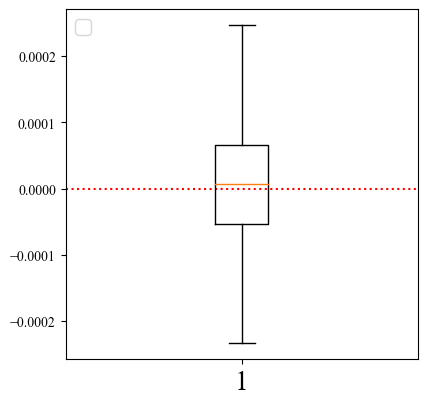

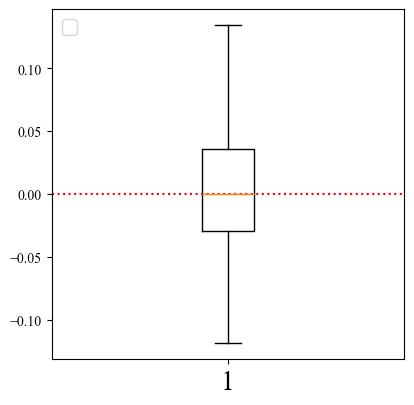

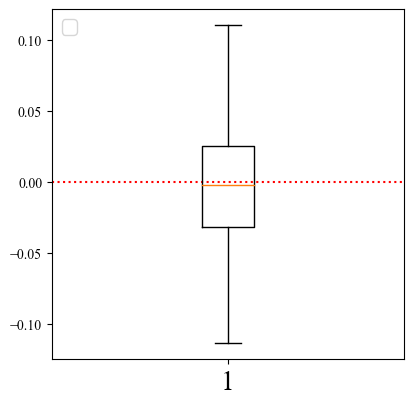

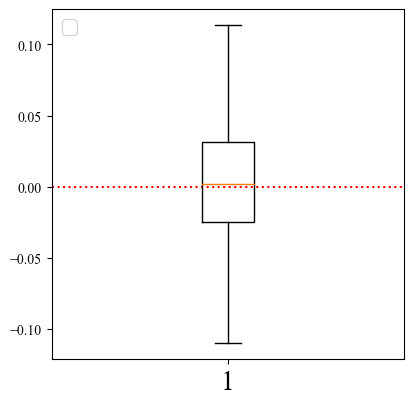

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.rc('font',family='Times New Roman')
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.xticks(fontsize=20)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
plt.boxplot(diff_parameters.cpu()[:,0].detach().numpy(),showfliers=False)
plt.xlabel("")
plt.ylabel("")
plt.legend(loc = 'upper left',fontsize=14)

plt.rc('font',family='Times New Roman')
plt.figure(figsize=(10,10))
plt.subplot(2,2,2)
plt.xticks(fontsize=20)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
plt.boxplot(diff_parameters.cpu()[:,1].detach().numpy(),showfliers=False)
plt.xlabel("")
plt.ylabel("")
plt.legend(loc = 'upper left',fontsize=14)

plt.rc('font',family='Times New Roman')
plt.figure(figsize=(10,10))
plt.subplot(2,2,3)
plt.xticks(fontsize=20)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
plt.boxplot(diff_parameters.cpu()[:,2].detach().numpy(),showfliers=False)
plt.xlabel("")
plt.ylabel("")
plt.legend(loc = 'upper left',fontsize=14)

plt.rc('font',family='Times New Roman')
plt.figure(figsize=(10,10))
plt.subplot(2,2,4)
plt.xticks(fontsize=20)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
plt.boxplot(diff_parameters.cpu()[:,3].detach().numpy(),showfliers=False)
plt.xlabel("")
plt.ylabel("")
plt.legend(loc = 'upper left',fontsize=14)

